# Before You Start

* **What is Embedding Model ?**
> - Processing text for NLP tasks requires a numeric representation of each word.
>* Embedding is the process of converting
data (text, image,...)
into vectors representation
\begin{equation}
data \rightarrow vector
\end{equation}
> * Embedding capture the semandtic reationship between words.
> * words with closer meanings or relationships are closer in the vector space than words that are less related.
> * the dim size of an embedding vector is different from model to model, smaller vectors (lower dimensions) are more efficient to keep in memory or to process, while bigger vectors (higher dimensions) can capture intricate relationships, but are prone to overfitting.


* **Static Vs Dynamic Embedding (Attention Models)?**

<center>

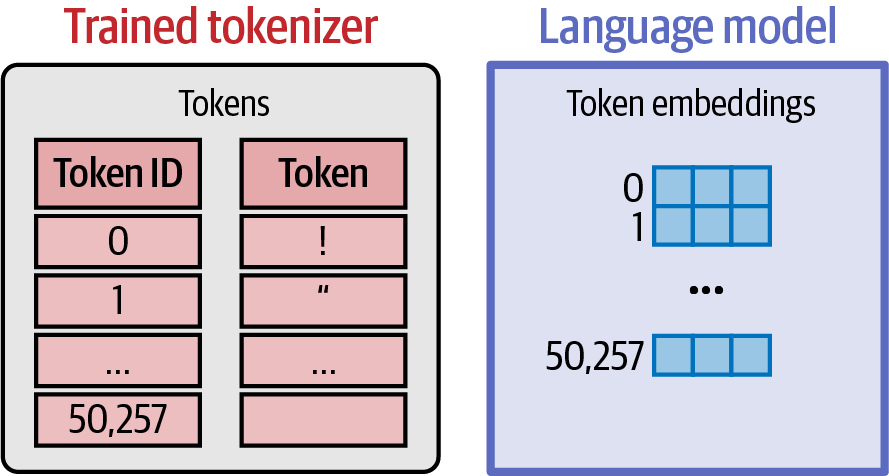
</center>

> - **Static embedding:** Each word or token is assigned a fixed vector representation, regardless of its context within a sentence or document. These vectors are typically pre-trained on a large corpus of text and remain unchanged during model training or inference.

<center>

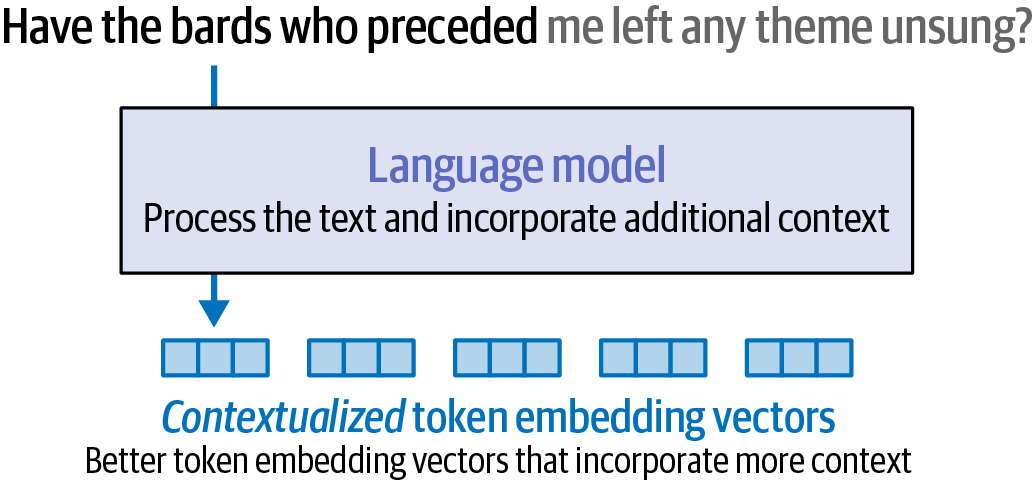
</center>

> - **Dynamic embedding:** Also known as contextual embeddings, these representations are generated on-the-fly, taking into account the context of the word within the input sequence. This allows the model to capture the nuanced meanings of words based on their surrounding words.

<center>

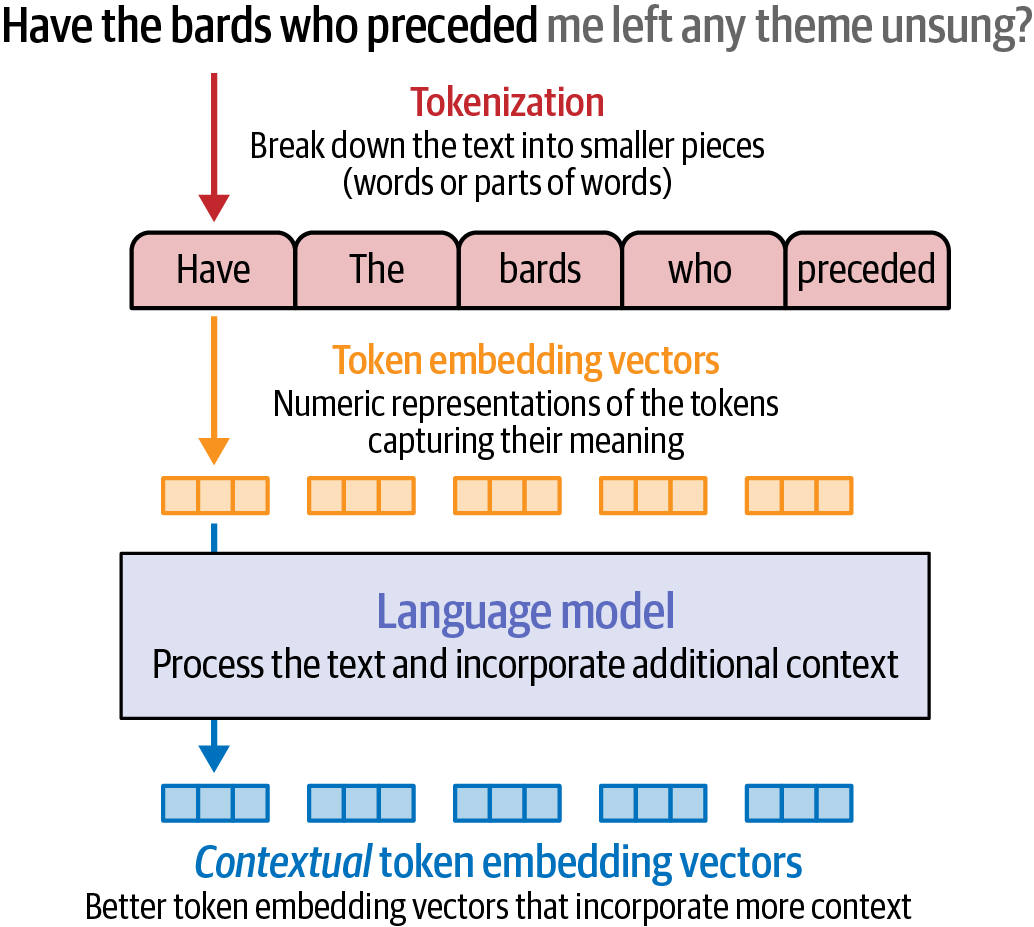
</center>

* ***BERT (Bidirectional encoder representations from transformers)***

> BERT inspired from the Transformer architecture introduced in "Attention is all you need", to become an encoder-only transformer that can produce meaningful representations and understand language.

> In the pretraining phase, BERT is trained to learn two tasks simultaneously:
1. **Masked Language Modeling**: is to predict masked words in a sentence (I [MASKED] this book before -> read)
2. **Next Sentence Prediction:** given two sentences, predict if A came before B or not. The special [SEP] token separates the two sentences and the task is similar to binary classification.

* ***why is BERT important?***

> BERT is among the first instances of Transformer-based contextualized, dynamic embeddings. When given a sentence as input, the layers of the BERT model use self-attention and feed-forward mechanisms to update and incorporate context from all other tokens in the sentence. The final output of each Transformer layer is a **contextualized representation of the word**.

* **How BERT Embedding Model Works with SentenceTransformers?***

>SentenceTransformers is a framework provides an easy method to compute embeddings for accessing, using, and training state-of-the-art embedding and reranker models.

  

1.   Compute Embedding
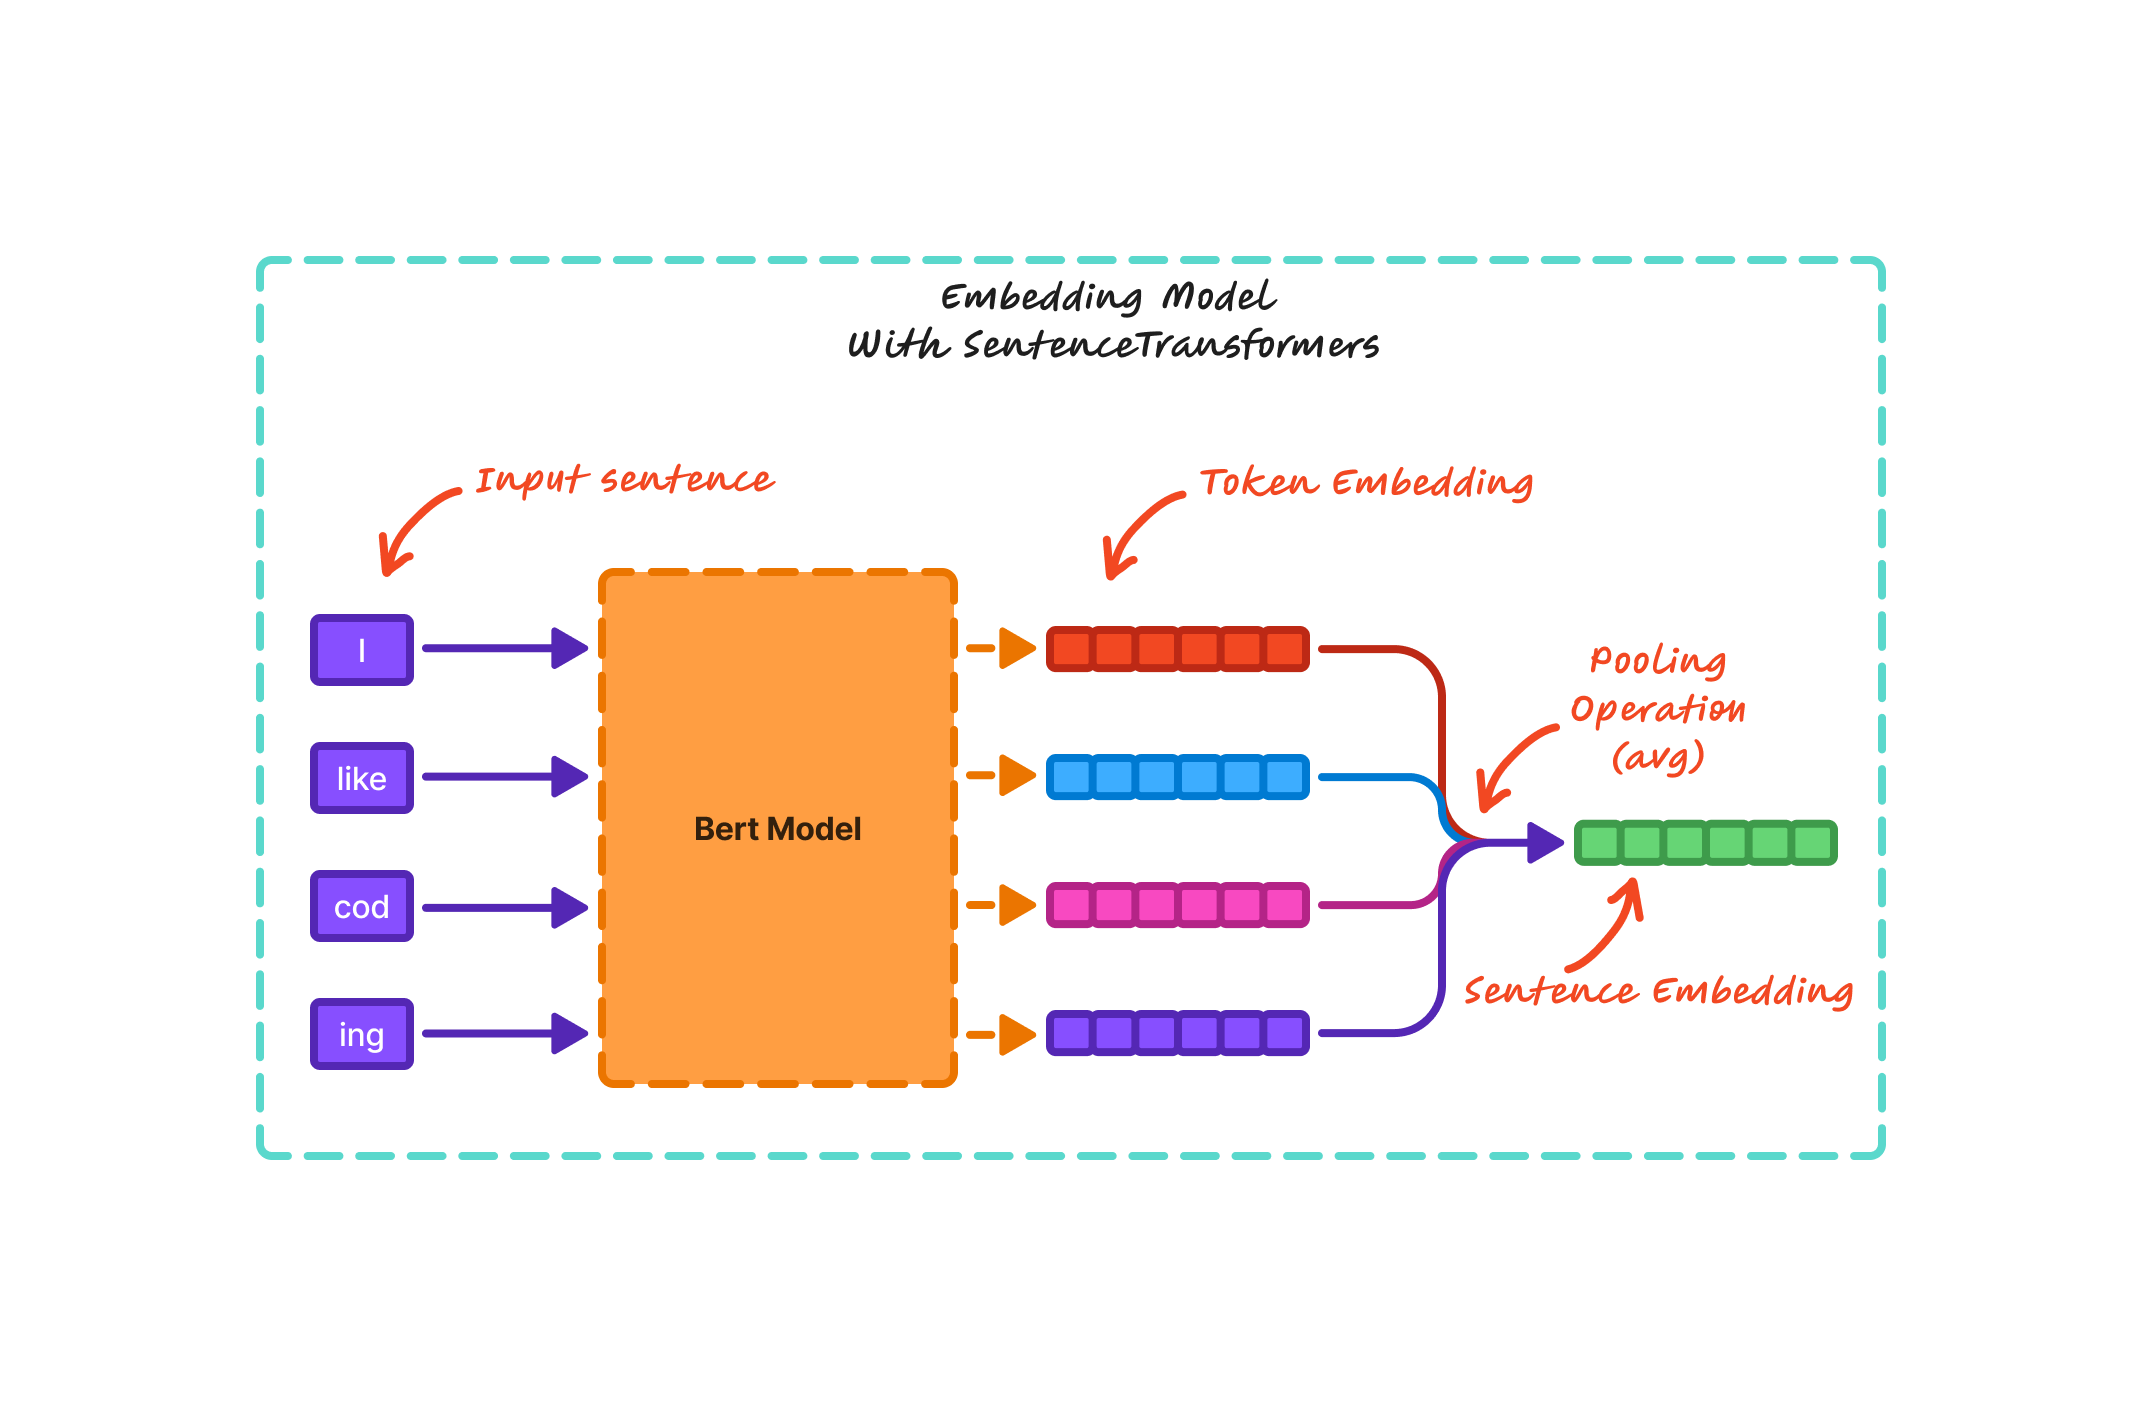

2.   Calculate Similarity

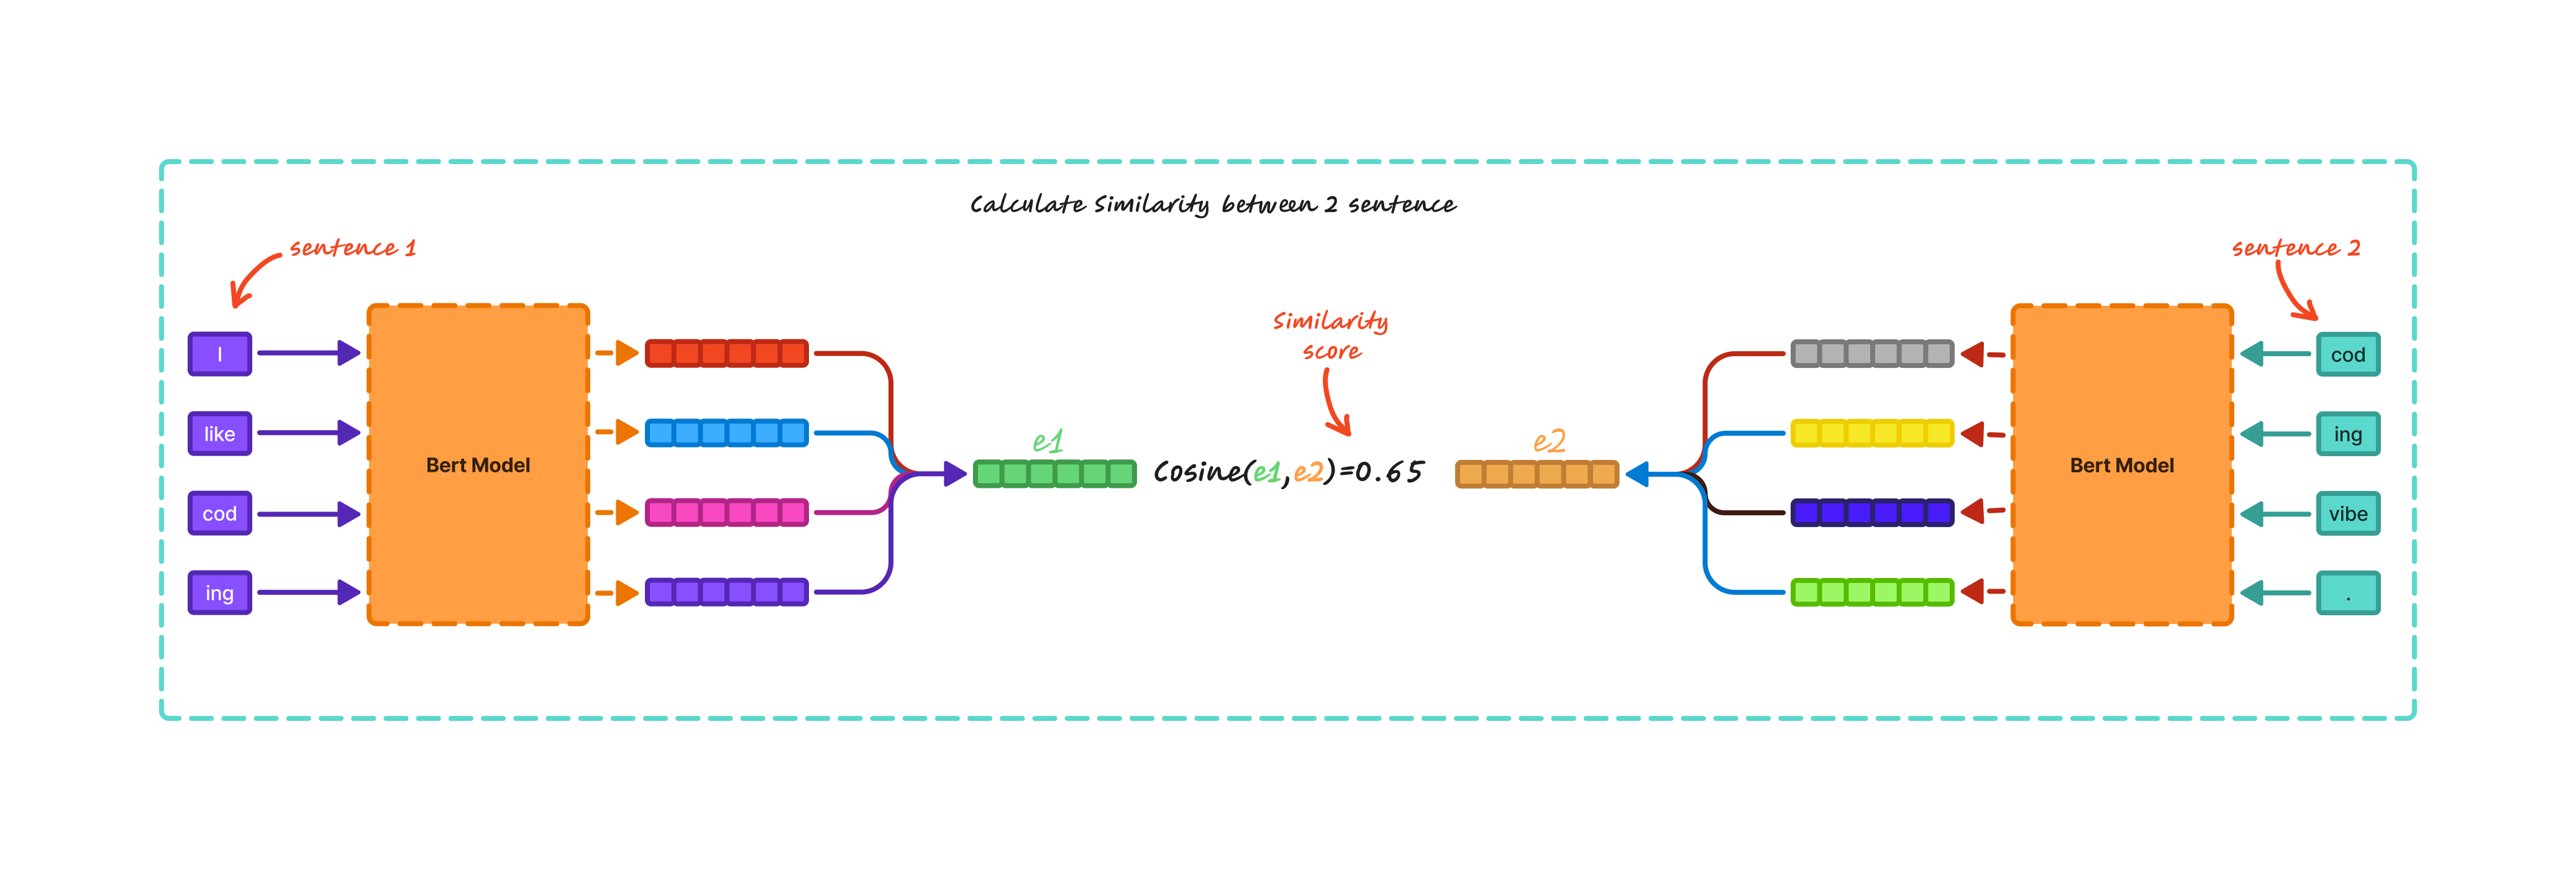


* ***Steps To Get Your Embedding Model***
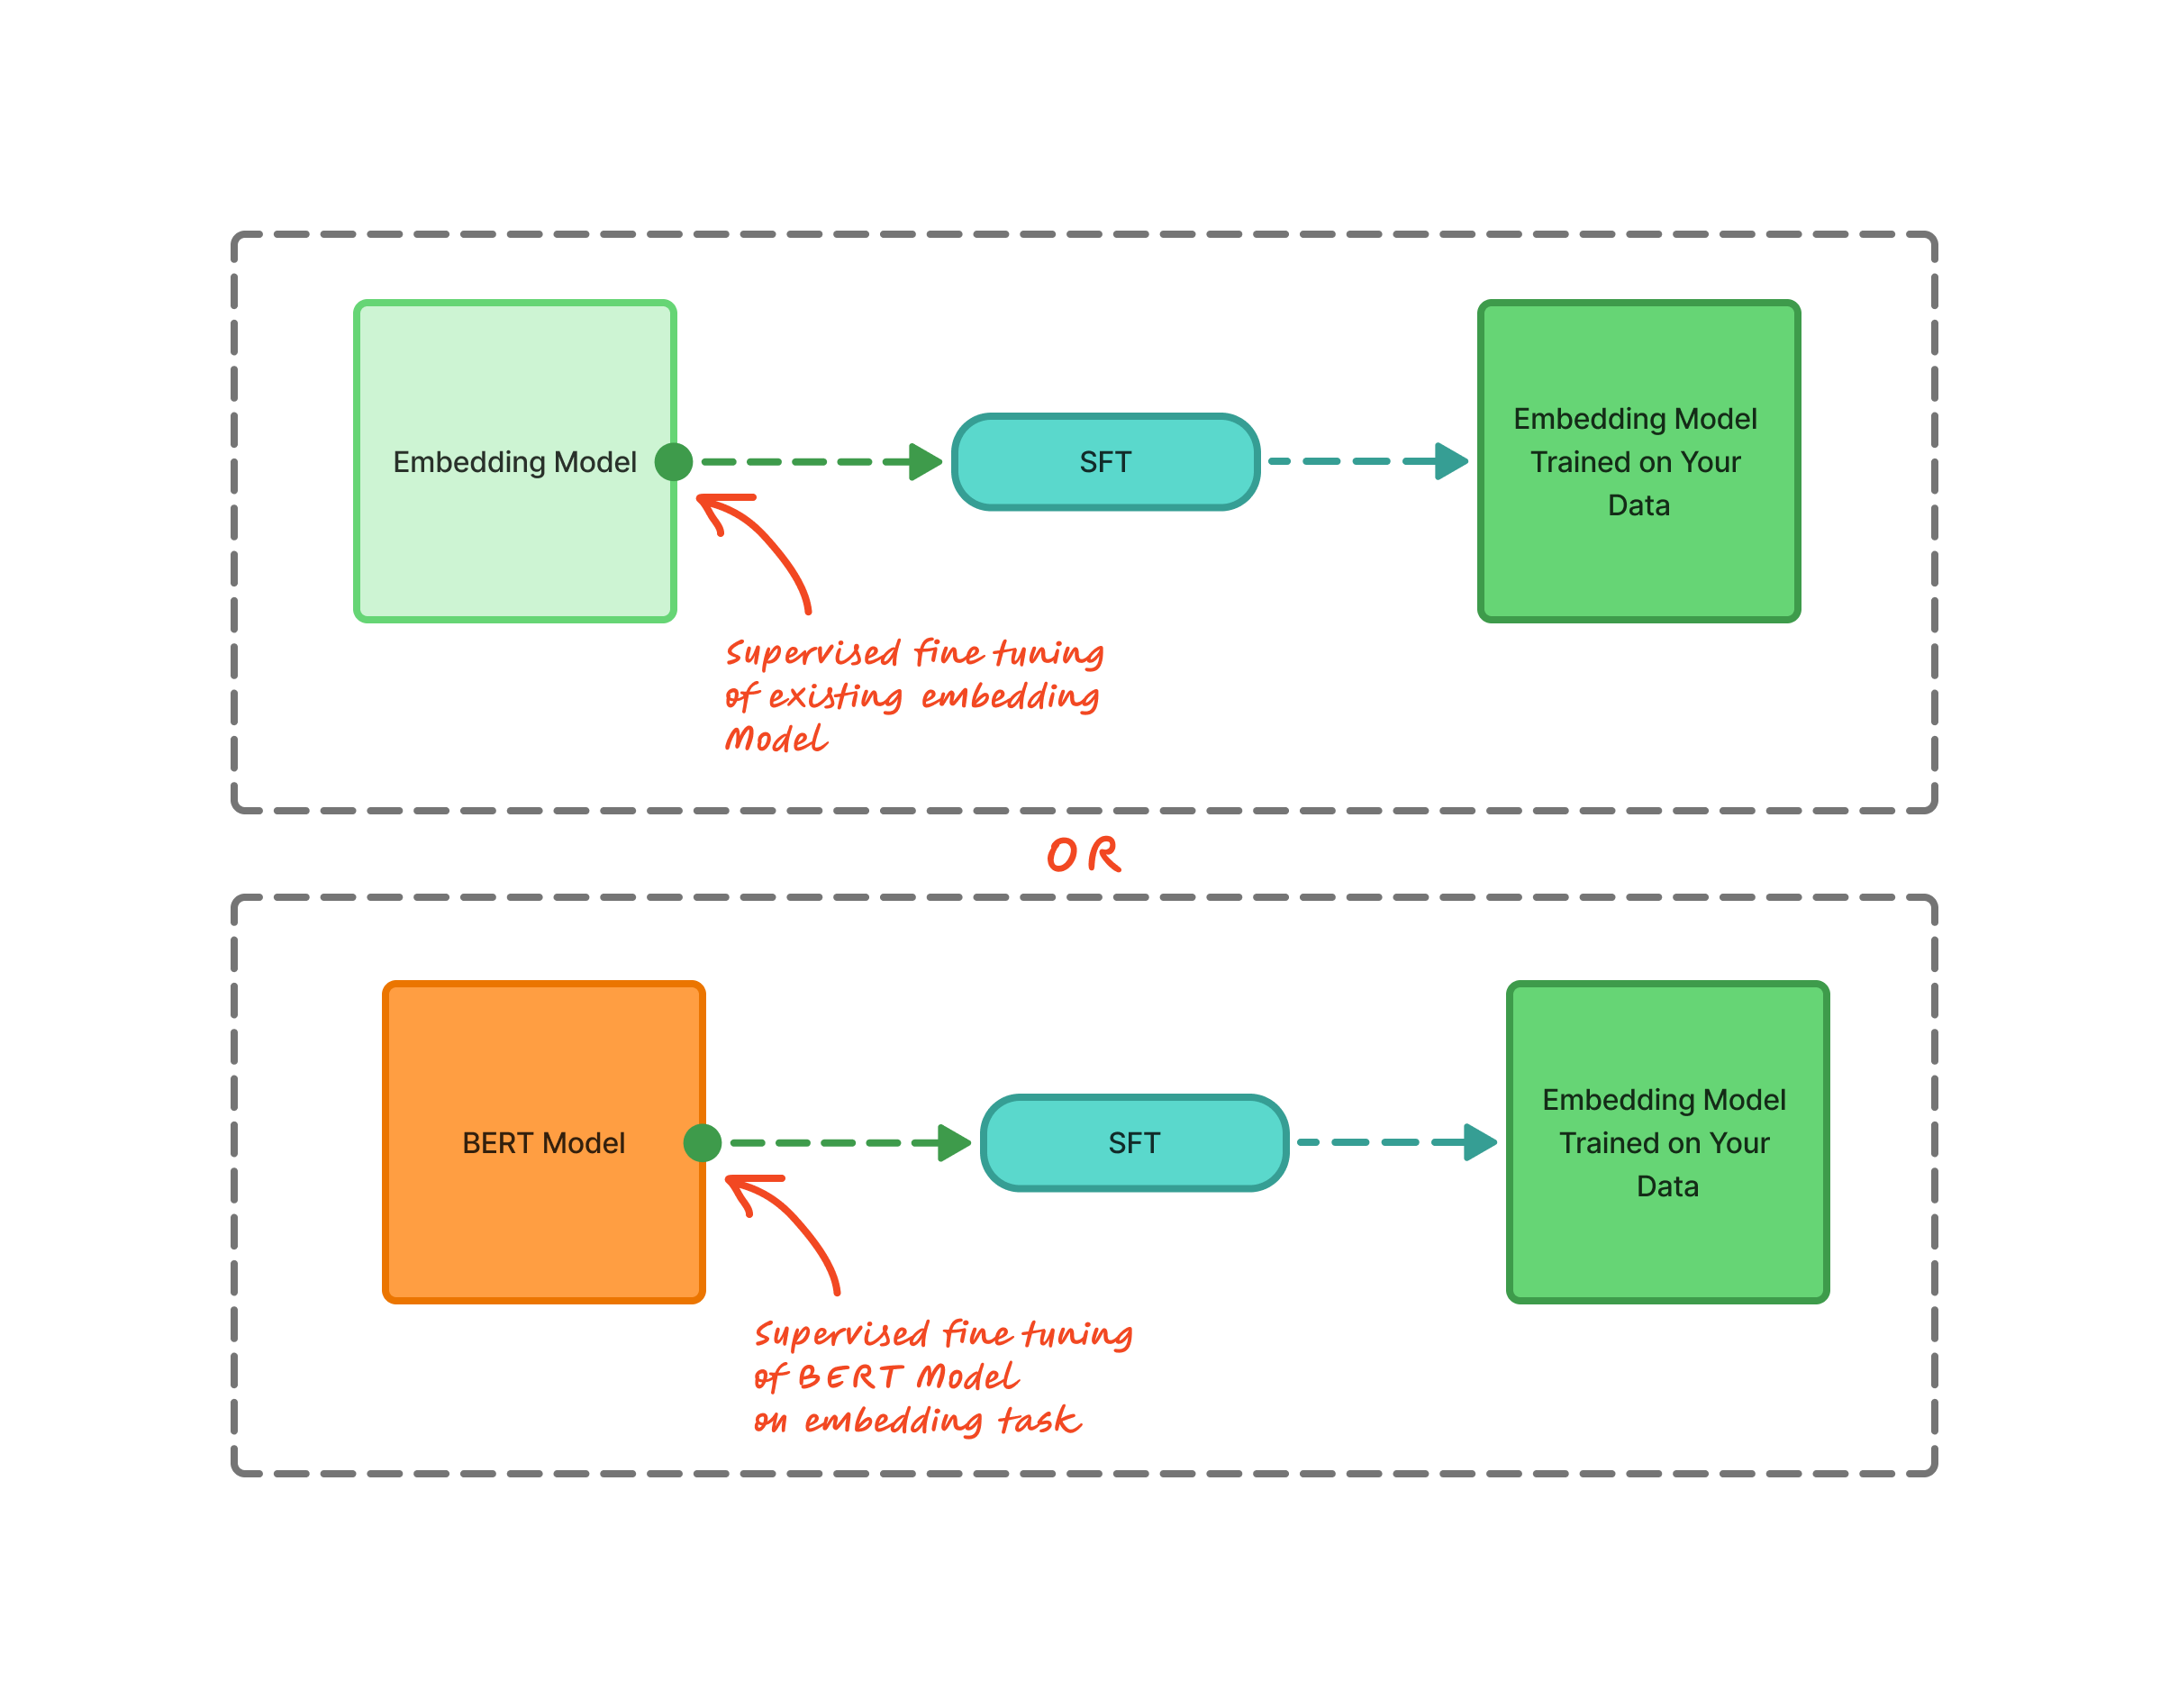

# Fine-tuning Embedding Model (SFT)

**In this stage, we can fine-tune our pretrained BERT model, or another selected embedding model.**
* We will fine-tune our selected model using the **[SBERT](https://sbert.net/)** library.
* To fine-tune an existing embedding model, you can use **[mteb leaderboard](https://huggingface.co/spaces/mteb/leaderboard)**.

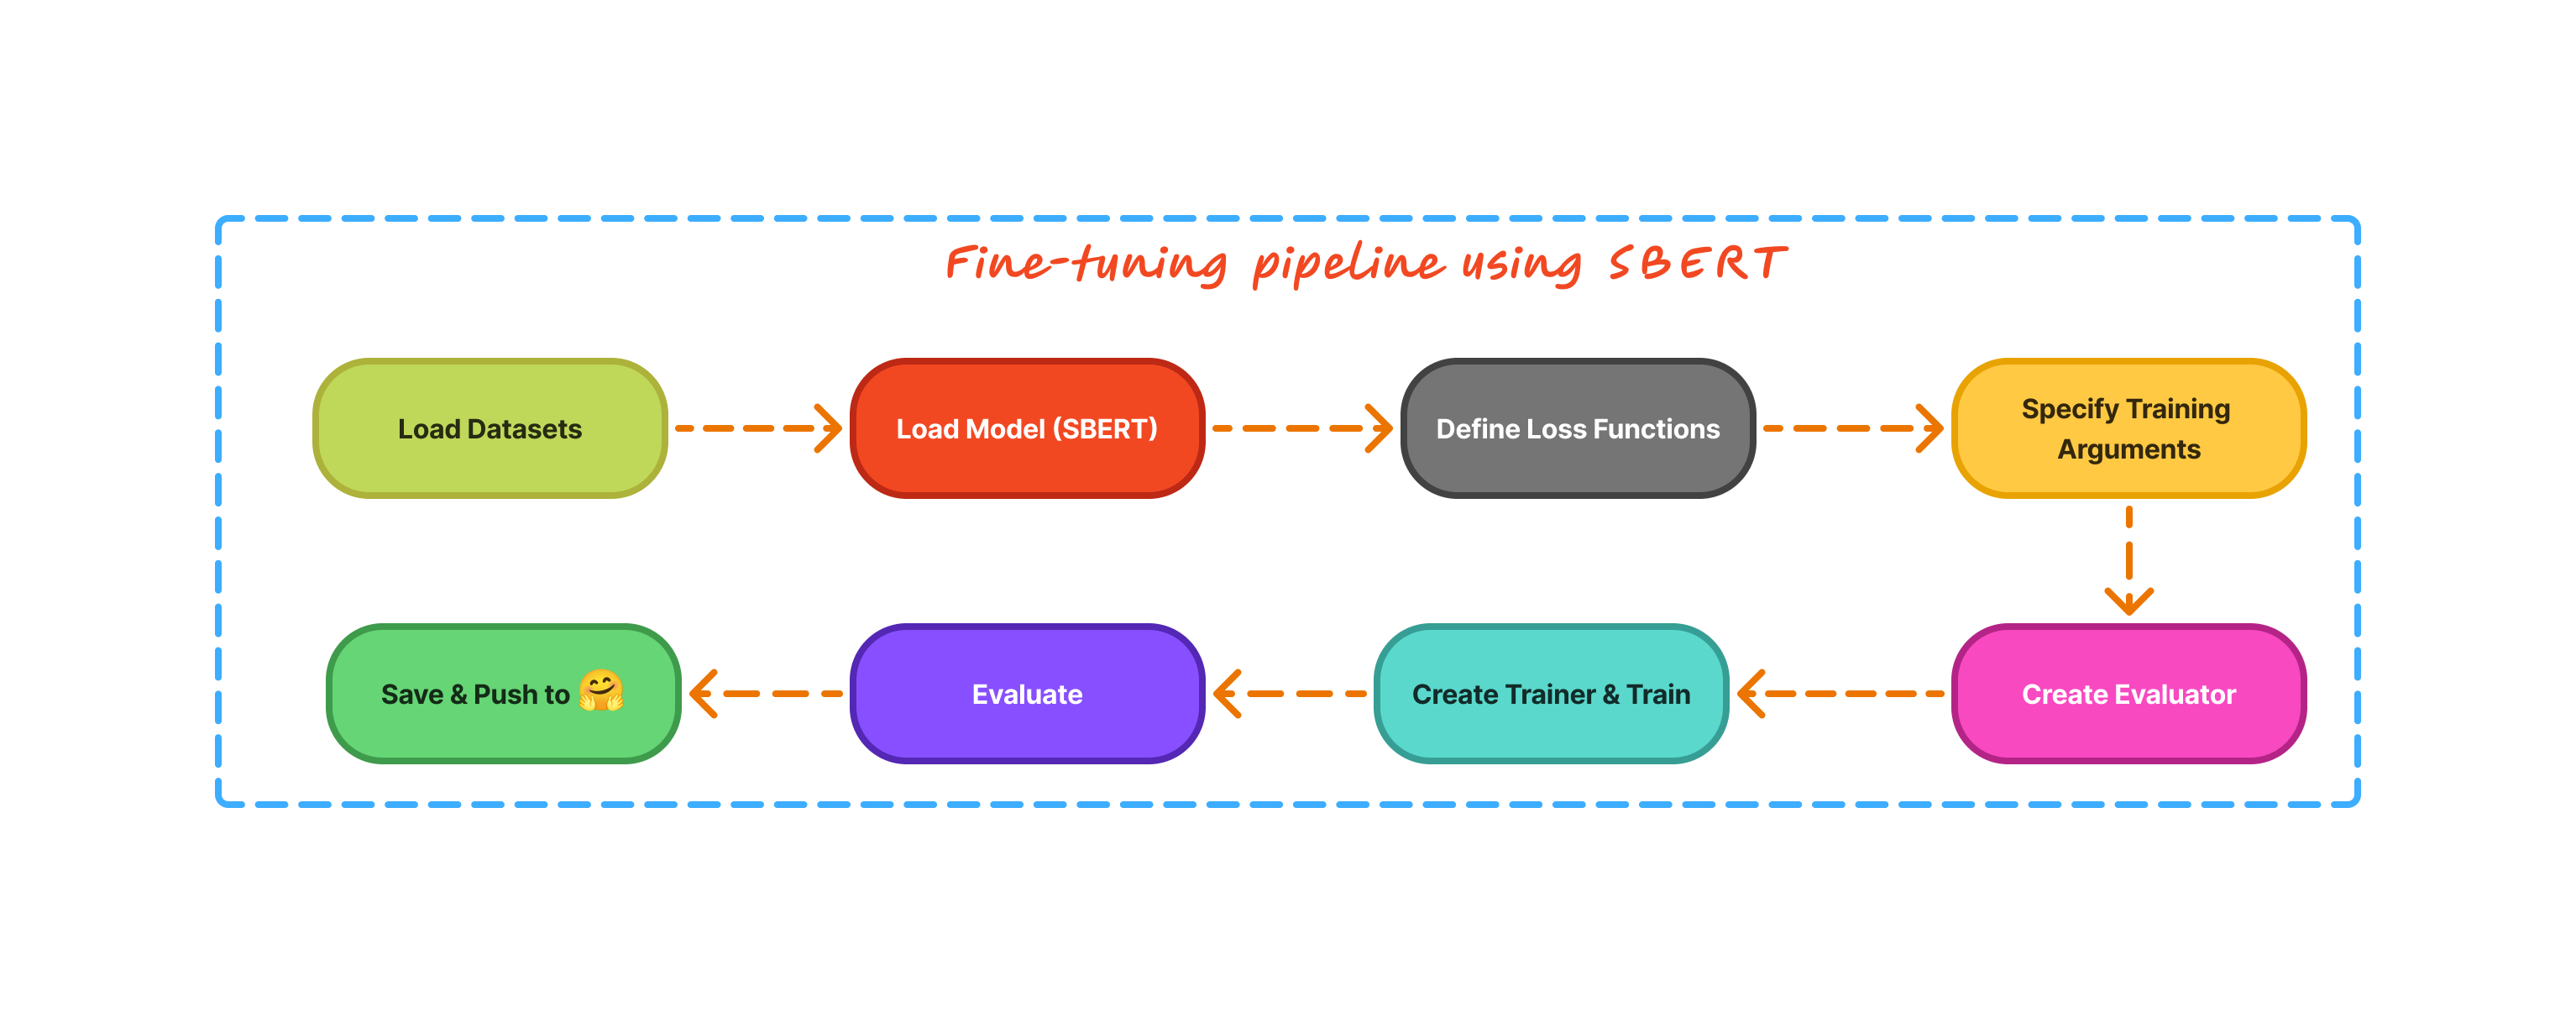

#### install requirements

In [1]:
! uv pip install -U datasets

Using Python 3.12.13 environment at: /usr
Resolved 42 packages in 209ms
Checked 42 packages in 0.93ms


In [2]:
# restart the kernel
exit()

#### HF Login

In [3]:
from google.colab import userdata
HF_TOKEN=userdata.get('HF_TOKEN')

In [4]:
# create a write token on HF
from huggingface_hub import login
login(HF_TOKEN)

#### Load Dataset

In [5]:
from datasets import load_dataset

In [6]:
ds_id="sentence-transformers/all-nli"
ds=load_dataset(ds_id,name="pair-score",split="train[:100]")
ds

README.md: 0.00B [00:00, ?B/s]

pair-score/train-00000-of-00001.parquet:   0%|          | 0.00/69.5M [00:00<?, ?B/s]

pair-score/dev-00000-of-00001.parquet:   0%|          | 0.00/1.57M [00:00<?, ?B/s]

pair-score/test-00000-of-00001.parquet:   0%|          | 0.00/1.61M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/942069 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/19657 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/19656 [00:00<?, ? examples/s]

Dataset({
    features: ['sentence1', 'sentence2', 'score'],
    num_rows: 100
})

In [7]:
ds.to_pandas().head(10)

,sentence1,sentence2,score
0,A person on a horse jumps over a broken down a...,A person is training his horse for a competition.,0.5
1,A person on a horse jumps over a broken down a...,"A person is at a diner, ordering an omelette.",0.0
2,A person on a horse jumps over a broken down a...,"A person is outdoors, on a horse.",1.0
3,Children smiling and waving at camera,They are smiling at their parents,0.5
4,Children smiling and waving at camera,There are children present,1.0
5,Children smiling and waving at camera,The kids are frowning,0.0
6,A boy is jumping on skateboard in the middle o...,The boy skates down the sidewalk.,0.0
7,A boy is jumping on skateboard in the middle o...,The boy does a skateboarding trick.,1.0
8,A boy is jumping on skateboard in the middle o...,The boy is wearing safety equipment.,0.5
9,An older man sits with his orange juice at a s...,An older man drinks his juice as he waits for ...,0.5


#### Split Dataset

In [8]:
ds=ds.train_test_split(test_size=0.2,shuffle=True)
train_dataset,eval_dataset=ds["train"],ds["test"]
train_dataset,eval_dataset

(Dataset({
     features: ['sentence1', 'sentence2', 'score'],
     num_rows: 80
 }),
 Dataset({
     features: ['sentence1', 'sentence2', 'score'],
     num_rows: 20
 }))

#### Load Model

In [9]:
from sentence_transformers import SentenceTransformer

In [10]:
model_id="abdeljalilELmajjodi/model"
model=SentenceTransformer(model_id)

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: abdeljalilELmajjodi/model
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

In [11]:
# test model
sentence="hello world"
s_embedding=model.encode(sentence) # calculate embedding of sentence
model.similarity(s_embedding,s_embedding) # calculate the similarity

tensor([[1.0000]])

#### Define Loss function(s)

[**How to select loss function?**](https://sbert.net/docs/cross_encoder/loss_overview.html)

<center>

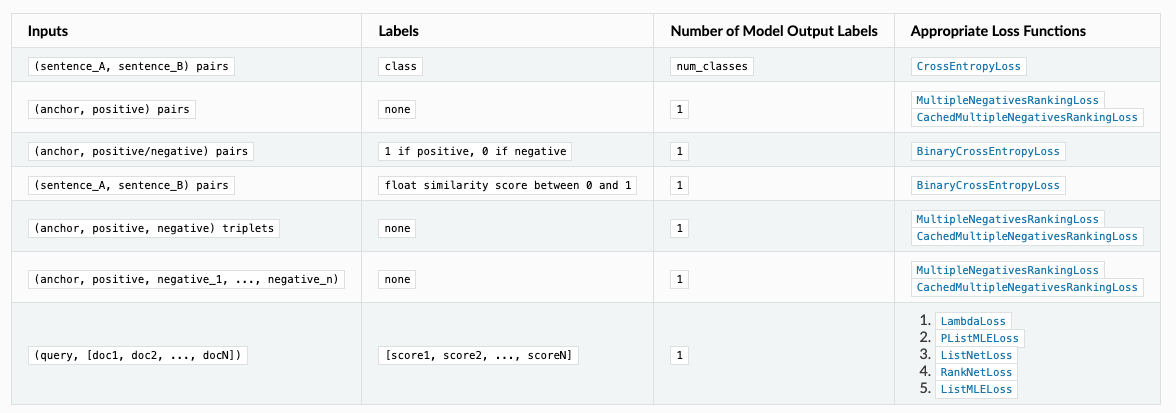
</center>

In [12]:
from sentence_transformers.losses import CoSENTLoss
loss=CoSENTLoss(model)

/tmp/ipykernel_644/3785492934.py:1: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers.losses import CoSENTLoss


#### Training Arguments

In [13]:
# Specify training arguments
from sentence_transformers.trainer import SentenceTransformerTrainingArguments
training_args = SentenceTransformerTrainingArguments(
    output_dir="./result_model",
    eval_strategy="steps",
    learning_rate=5e-5,
    warmup_ratio=0.05,
    gradient_accumulation_steps=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    save_total_limit=1,
    bf16=True,
    fp16_full_eval=True,
    logging_steps=5,
    save_steps=10,
    eval_steps=10,
    report_to="wandb",
    push_to_hub=True,
    gradient_checkpointing=True,
    load_best_model_at_end=True,
    logging_first_step=True,
)

/tmp/ipykernel_644/169609401.py:2: DeprecationWarning: Importing from 'sentence_transformers.trainer' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.trainer' instead.
  from sentence_transformers.trainer import SentenceTransformerTrainingArguments


#### Evaluator

[**How to select the right evaluator?**](https://sbert.net/docs/sentence_transformer/training_overview.html#evaluator)

<center>

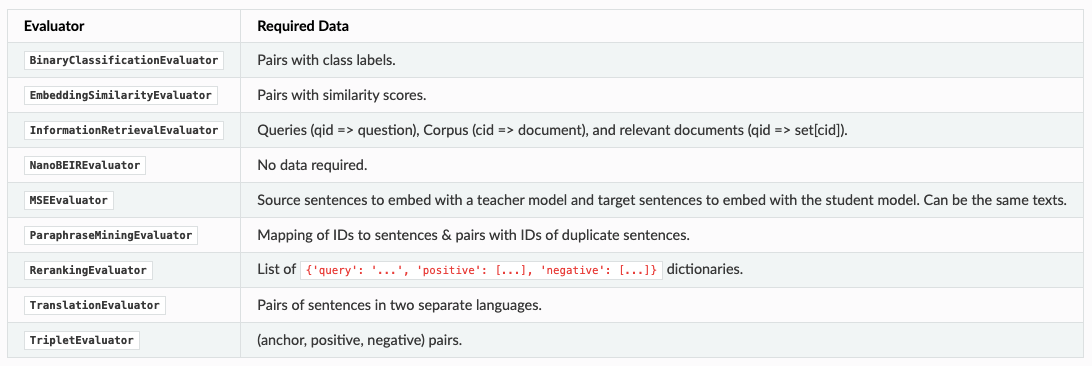
</center>

In [14]:
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
pair_score_evaluator = EmbeddingSimilarityEvaluator(
    sentences1=eval_dataset["sentence1"],
    sentences2=eval_dataset["sentence2"],
    scores=eval_dataset["score"],
    name="pair-score-evaluator-dev",

)

/tmp/ipykernel_644/3487794634.py:1: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator


#### Create Trainer

In [15]:
from sentence_transformers.trainer import SentenceTransformerTrainer
trainer = SentenceTransformerTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    loss=loss,
    evaluator=pair_score_evaluator,
)

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

In [16]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss,Validation Loss,Pair-score-evaluator-dev Pearson Cosine,Pair-score-evaluator-dev Spearman Cosine
10,3.018507,2.632595,-0.128437,-0.129456


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

TrainOutput(global_step=10, training_loss=3.0662778854370116, metrics={'train_runtime': 267.9763, 'train_samples_per_second': 0.299, 'train_steps_per_second': 0.037, 'total_flos': 0.0, 'train_loss': 3.0662778854370116, 'epoch': 1.0})

#### Push Model To HF 🤗

In [17]:
trainer.push_to_hub("Haitam03/hack_ai_embbedding_model")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...t_model/training_args.bin: 100%|##########| 5.52kB / 5.52kB            

  ...sult_model/tokenizer.json: 100%|##########| 16.8MB / 16.8MB            

  ...t_model/model.safetensors:   8%|7         |  176MB / 2.24GB            

CommitInfo(commit_url='https://huggingface.co/Haitam03/result_model/commit/f969d4042a1b77dfe8b0540aae4dc9e19b6c837d', commit_message='Haitam03/hack_ai_embbedding_model', commit_description='', oid='f969d4042a1b77dfe8b0540aae4dc9e19b6c837d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Haitam03/result_model', endpoint='https://huggingface.co', repo_type='model', repo_id='Haitam03/result_model'), pr_revision=None, pr_num=None)

<center>

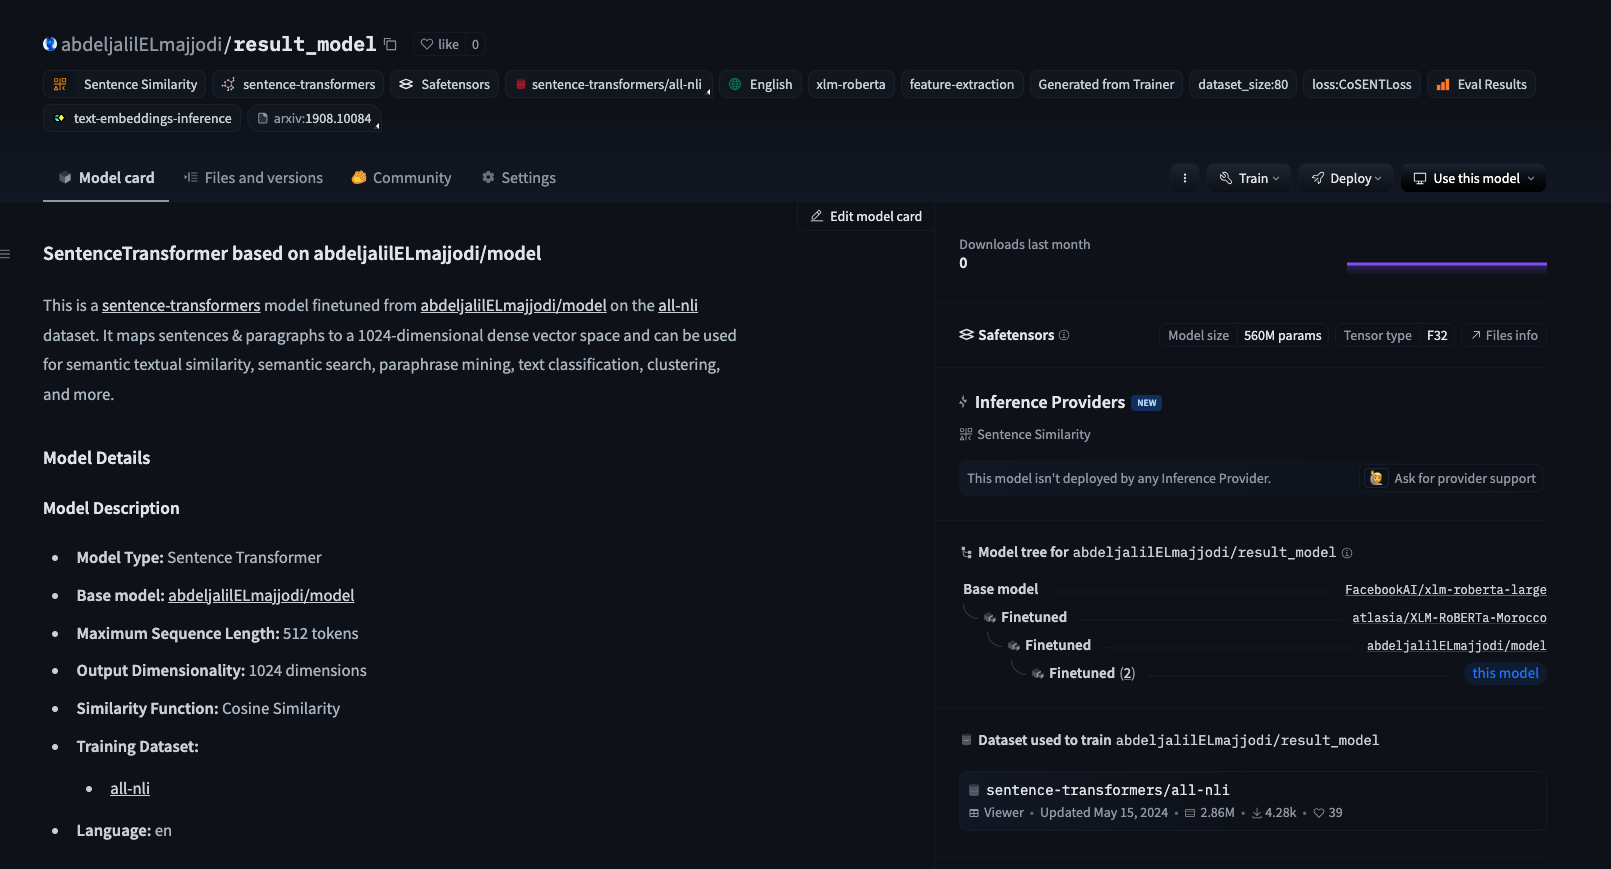

</center>

**bold text**## Show Your Work (Model Space) at Hugging Face

**In this final step, you will create a Gradio Space on Hugging Face to showcase your work. Follow these steps:**

1. **Clone the repository** from this [space](https://huggingface.co/spaces/atlasia/Masked-LM-Moroccan-Darija).

<center>

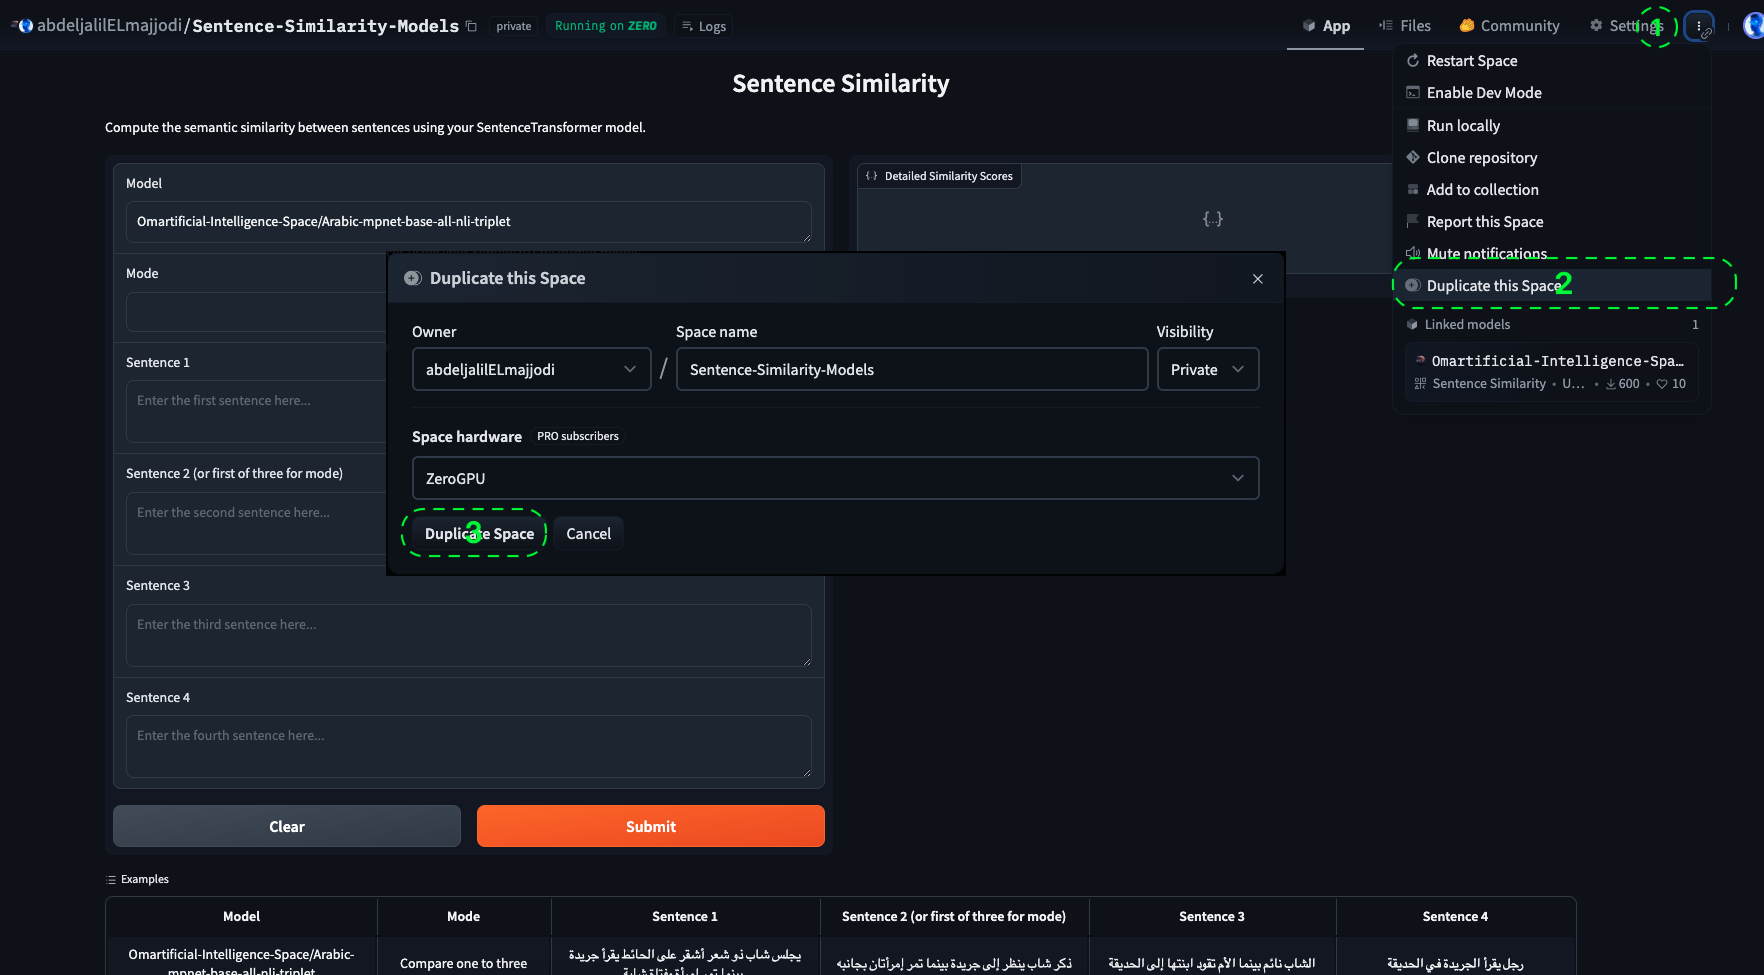
</center>

2. **Open the code files** and **replace the model ID** with the ID of your own trained Embedding model.

</center>

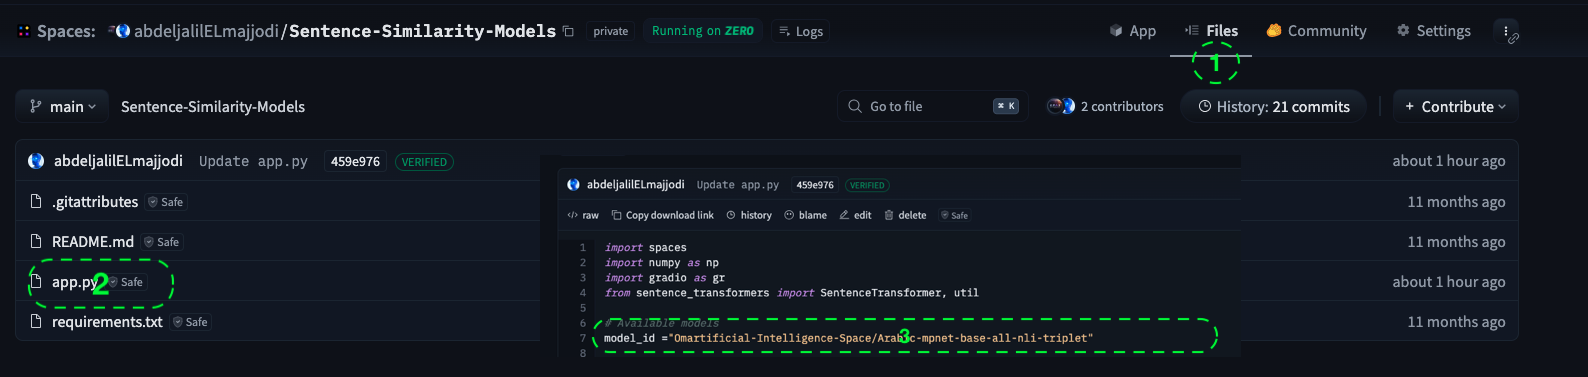
</center>

3. **Update the example inputs** to be compatible with your model’s expected format (e.g., appropriate masked sentences).
4. **Save and commit your changes**, then save changes.
